# Análise Comparativa — Aprendizado Multitarefa para Detecção de Quedas

**CIC1205 — Machine Learning | Trabalho 3 — Tema 2**

Este notebook analisa e compara:
- Modelos **single-task** (detecção de queda apenas)
- Modelos **multi-task** (detecção de queda + classificação da orientação final da queda)

Arquitetura base: **CNN1Conv**
Validação: **Leave-One-Subject-Out (LOSO)** com os 14 sujeitos  
Sensores: **CHEST**, **LEFT**, **RIGHT** e ensembles por Late Fusion

---
## Design do Modelo Multi-Tarefa

```
Sinais inerciais de entrada (janela 5s, 90Hz, 8 canais)
            ↓
   Bloco compartilhado (CNN1D)
            ↓
   Representação latente compartilhada
       ↙           ↘
Head 1: queda    Head 2: orientação final
(binário, CE)    (4 classes, CE com máscara)
```

**Função de perda:** `L_total = L_queda + λ * L_orientacao`  
**Estratégia de rótulo:** Máscara de loss — não-quedas têm rótulo -1 em `y_classify_fall` e não contribuem para a Head 2.

**Classes da Head 2 (orientação final da queda):**
- 0: BACKWARD-FALL (queda para trás → termina de costas / supine)
- 1: FRONTAL-FALL (queda para frente → termina de bruços / prone)
- 2: LATERAL-FALL-LEFT (queda lateral esquerda)
- 3: LATERAL-FALL-RIGHT (queda lateral direita)

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

warnings.filterwarnings("ignore")

RESULTS_DIR = Path("results/5-sec_1-step")
WINDOW_TAG = "5-sec_1-step"

# Rótulos das classes
FALL_DETECT_LABELS = {0: "Queda", 1: "Não-Queda"}
FALL_CLASSIFY_LABELS = {
    0: "Backward\n(costas)",
    1: "Frontal\n(bruços)",
    2: "Lateral\nEsquerda",
    3: "Lateral\nDireita",
}

SENSOR_ORDER = [
    "CHEST", "LEFT", "RIGHT",
    "CHEST_LEFT", "CHEST_RIGHT", "LEFT_RIGHT", "CHEST_LEFT_RIGHT",
    "ENSEMBLE_CHEST_LEFT", "ENSEMBLE_CHEST_RIGHT",
    "ENSEMBLE_LEFT_RIGHT", "ENSEMBLE_CHEST_LEFT_RIGHT",
]

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

---
## 1. Funções Auxiliares

In [4]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def find_results(pattern):
    """Retorna lista de arquivos JSON que batem com o padrão glob."""
    return sorted(RESULTS_DIR.glob(pattern))


def mcc_from_cm(tp, fp, fn, tn):
    num = tp * tn - fp * fn
    den = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    return num / den if den > 0 else 0.0


def specificity_from_cm(fp, tn):
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def extract_binary_metrics(fold):
    """Extrai métricas binárias de um fold (fall = classe 0)."""
    tp = fold.get("tp", 0)
    fp = fold.get("fp", 0)
    fn = fold.get("fn", 0)
    tn = fold.get("tn", 0)
    return {
        "accuracy": fold.get("accuracy", 0.0),
        "precision": fold.get("precision", 0.0),
        "recall": fold.get("recall", 0.0),
        "f1": fold.get("f1", 0.0),
        "specificity": specificity_from_cm(fp, tn),
        "mcc": mcc_from_cm(tp, fp, fn, tn),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


def aggregate_binary_folds(folds):
    """Agrega métricas de todos os folds LOSO (média ± desvio)."""
    metrics_list = [extract_binary_metrics(f) for f in folds]
    keys = ["accuracy", "precision", "recall", "f1", "specificity", "mcc"]
    agg = {}
    for k in keys:
        vals = [m[k] for m in metrics_list]
        agg[f"{k}_mean"] = np.mean(vals)
        agg[f"{k}_std"] = np.std(vals)
    # Matriz de confusão agregada
    agg["tp_total"] = sum(m["tp"] for m in metrics_list)
    agg["fp_total"] = sum(m["fp"] for m in metrics_list)
    agg["fn_total"] = sum(m["fn"] for m in metrics_list)
    agg["tn_total"] = sum(m["tn"] for m in metrics_list)
    return agg


def aggregate_multiclass_folds(folds, n_classes):
    """Agrega métricas multiclasse de folds LOSO."""
    keys = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
    agg = {}
    for k in keys:
        vals = [f.get(k, 0.0) for f in folds]
        agg[f"{k}_mean"] = np.mean(vals)
        agg[f"{k}_std"] = np.std(vals)
    # Matriz de confusão agregada
    agg_cm = np.zeros((n_classes, n_classes), dtype=int)
    for fold in folds:
        cm = fold.get("confusion_matrix")
        if cm is not None:
            cm_arr = np.array(cm)
            if cm_arr.shape == (n_classes, n_classes):
                agg_cm += cm_arr
    agg["confusion_matrix"] = agg_cm
    return agg


def plot_confusion_matrix(cm, labels, title, ax=None, normalize=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    if normalize:
        with np.errstate(divide="ignore", invalid="ignore"):
            cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_plot = np.nan_to_num(cm_plot)
        fmt = ".2f"
        vmax = 1.0
    else:
        cm_plot = cm
        fmt = "d"
        vmax = cm.max() or 1
    sns.heatmap(
        cm_plot, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        vmin=0, vmax=vmax, ax=ax, linewidths=0.5,
    )
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(title)
    return ax

---
## 2. Carregamento dos Resultados

In [6]:
# ── Single-task: detecção de queda ──────────────────────────────────────────
# Arquivos: results/<window>/cnn/results_y_detect_fall_<model>_full_imu.json
#           results/<window>/logreg/results_y_detect_fall_logreg_full_imu.json

SINGLE_TASK_MODELS = ["cnn1conv", "deepconvlstm", "logreg"]
MULTITASK_MODE = "FALL_DETECT_FALL_CLASSIFY"
MULTITASK_MT_MODELS = ["cnn1conv"]  # expande para deepconvlstm se disponível

single_task_results = {}   # {model: {sensor: metrics}}
multitask_results = {}     # {sensor: {task: metrics}}

# Carrega single-task
for model in SINGLE_TASK_MODELS:
    # CNN e DeepConvLSTM ficam em 'cnn/', LOGREG em 'logreg/'
    folder = "logreg" if model == "logreg" else "cnn"
    path = RESULTS_DIR / folder / f"results_y_detect_fall_{model}_full_imu.json"
    if path.exists():
        data = load_json(path)
        single_task_results[model] = data
        print(f"[OK] Single-task {model.upper()}: {path.name}")
    else:
        print(f"[FALTANDO] {path}")

# Carrega multi-task
for model in MULTITASK_MT_MODELS:
    path = RESULTS_DIR / "cnn" / f"results_multitask_{MULTITASK_MODE}_{model}.json"
    if path.exists():
        data = load_json(path)
        # Reorganiza por sensor
        for sensor, tasks in data.items():
            if sensor not in multitask_results:
                multitask_results[sensor] = {}
            multitask_results[sensor].update(tasks)
        print(f"[OK] Multi-task {model.upper()} ({MULTITASK_MODE}): {path.name}")
    else:
        print(f"[FALTANDO] {path}")

if not single_task_results and not multitask_results:
    print("\nNenhum resultado encontrado. Executar src/train.py.")
else:
    available_sensors = set()
    for data in single_task_results.values():
        available_sensors.update(data.keys())
    print(f"\nSensores disponíveis: {sorted(available_sensors)}")

[OK] Single-task CNN1CONV: results_y_detect_fall_cnn1conv_full_imu.json
[FALTANDO] results\5-sec_1-step\cnn\results_y_detect_fall_deepconvlstm_full_imu.json
[OK] Single-task LOGREG: results_y_detect_fall_logreg_full_imu.json
[OK] Multi-task CNN1CONV (FALL_DETECT_FALL_CLASSIFY): results_multitask_FALL_DETECT_FALL_CLASSIFY_cnn1conv.json

Sensores disponíveis: ['CHEST', 'ENSEMBLE_CHEST_LEFT', 'ENSEMBLE_CHEST_LEFT_RIGHT', 'ENSEMBLE_CHEST_RIGHT', 'ENSEMBLE_LEFT_RIGHT', 'LEFT', 'RIGHT']


---
## 3. Métricas de Detecção de Queda — Single-Task vs Multi-Task

In [7]:
def build_detection_table(single_task_results, multitask_results, sensors=None):
    """Constrói tabela comparativa de detecção de queda para todos os modelos/sensores."""
    rows = []
    if sensors is None:
        sensors = ["CHEST", "LEFT", "RIGHT",
                   "ENSEMBLE_CHEST_LEFT", "ENSEMBLE_CHEST_RIGHT",
                   "ENSEMBLE_LEFT_RIGHT", "ENSEMBLE_CHEST_LEFT_RIGHT"]

    # Single-task models
    for model, data in single_task_results.items():
        for sensor in sensors:
            if sensor not in data:
                continue
            folds = data[sensor].get("folds", [])
            if not folds:
                continue
            agg = aggregate_binary_folds(folds)
            rows.append({
                "Modelo": f"Single-task {model.upper()}",
                "Sensor": sensor,
                "Acurácia": agg["accuracy_mean"],
                "Precisão": agg["precision_mean"],
                "Revocação": agg["recall_mean"],
                "Especificidade": agg["specificity_mean"],
                "F1": agg["f1_mean"],
                "MCC": agg["mcc_mean"],
                "Acurácia±": agg["accuracy_std"],
                "F1±": agg["f1_std"],
            })

    # Multi-task fall detection head
    for sensor, tasks in multitask_results.items():
        if sensor not in sensors:
            continue
        fall_folds = tasks.get("fall", {}).get("folds", [])
        if not fall_folds:
            continue
        agg = aggregate_binary_folds(fall_folds)
        rows.append({
            "Modelo": "Multi-task CNN1Conv",
            "Sensor": sensor,
            "Acurácia": agg["accuracy_mean"],
            "Precisão": agg["precision_mean"],
            "Revocação": agg["recall_mean"],
            "Especificidade": agg["specificity_mean"],
            "F1": agg["f1_mean"],
            "MCC": agg["mcc_mean"],
            "Acurácia±": agg["accuracy_std"],
            "F1±": agg["f1_std"],
        })

    return pd.DataFrame(rows)


df_detect = build_detection_table(single_task_results, multitask_results)

if df_detect.empty:
    print("Sem dados para exibir. Execute o treinamento primeiro.")
else:
    display_cols = ["Modelo", "Sensor", "Acurácia", "Precisão", "Revocação",
                    "Especificidade", "F1", "MCC"]
    styled = (
        df_detect[display_cols]
        .style
        .format({c: "{:.3f}" for c in display_cols[2:]})
        .background_gradient(subset=["F1", "MCC"], cmap="RdYlGn", vmin=0, vmax=1)
        .set_caption("Tabela 1 — Detecção de Queda: Single-Task vs Multi-Task (média LOSO)")
    )
    display(styled)

,Modelo,Sensor,Acurácia,Precisão,Revocação,Especificidade,F1,MCC
0,Single-task CNN1CONV,CHEST,0.964,0.736,0.914,0.968,0.783,0.789
1,Single-task CNN1CONV,LEFT,0.960,0.665,0.859,0.967,0.737,0.730
2,Single-task CNN1CONV,RIGHT,0.969,0.714,0.914,0.973,0.796,0.790
3,Single-task CNN1CONV,ENSEMBLE_CHEST_LEFT,0.975,0.753,0.944,0.977,0.833,0.829
4,Single-task CNN1CONV,ENSEMBLE_CHEST_RIGHT,0.979,0.773,0.949,0.981,0.848,0.845
5,Single-task CNN1CONV,ENSEMBLE_LEFT_RIGHT,0.980,0.793,0.934,0.983,0.855,0.849
6,Single-task CNN1CONV,ENSEMBLE_CHEST_LEFT_RIGHT,0.981,0.810,0.943,0.984,0.866,0.862
7,Single-task LOGREG,CHEST,0.989,0.930,0.898,0.995,0.913,0.908
8,Single-task LOGREG,LEFT,0.980,0.860,0.797,0.992,0.825,0.816
9,Single-task LOGREG,RIGHT,0.985,0.900,0.846,0.994,0.870,0.864


---
## 4. Matrizes de Confusão — Detecção de Queda

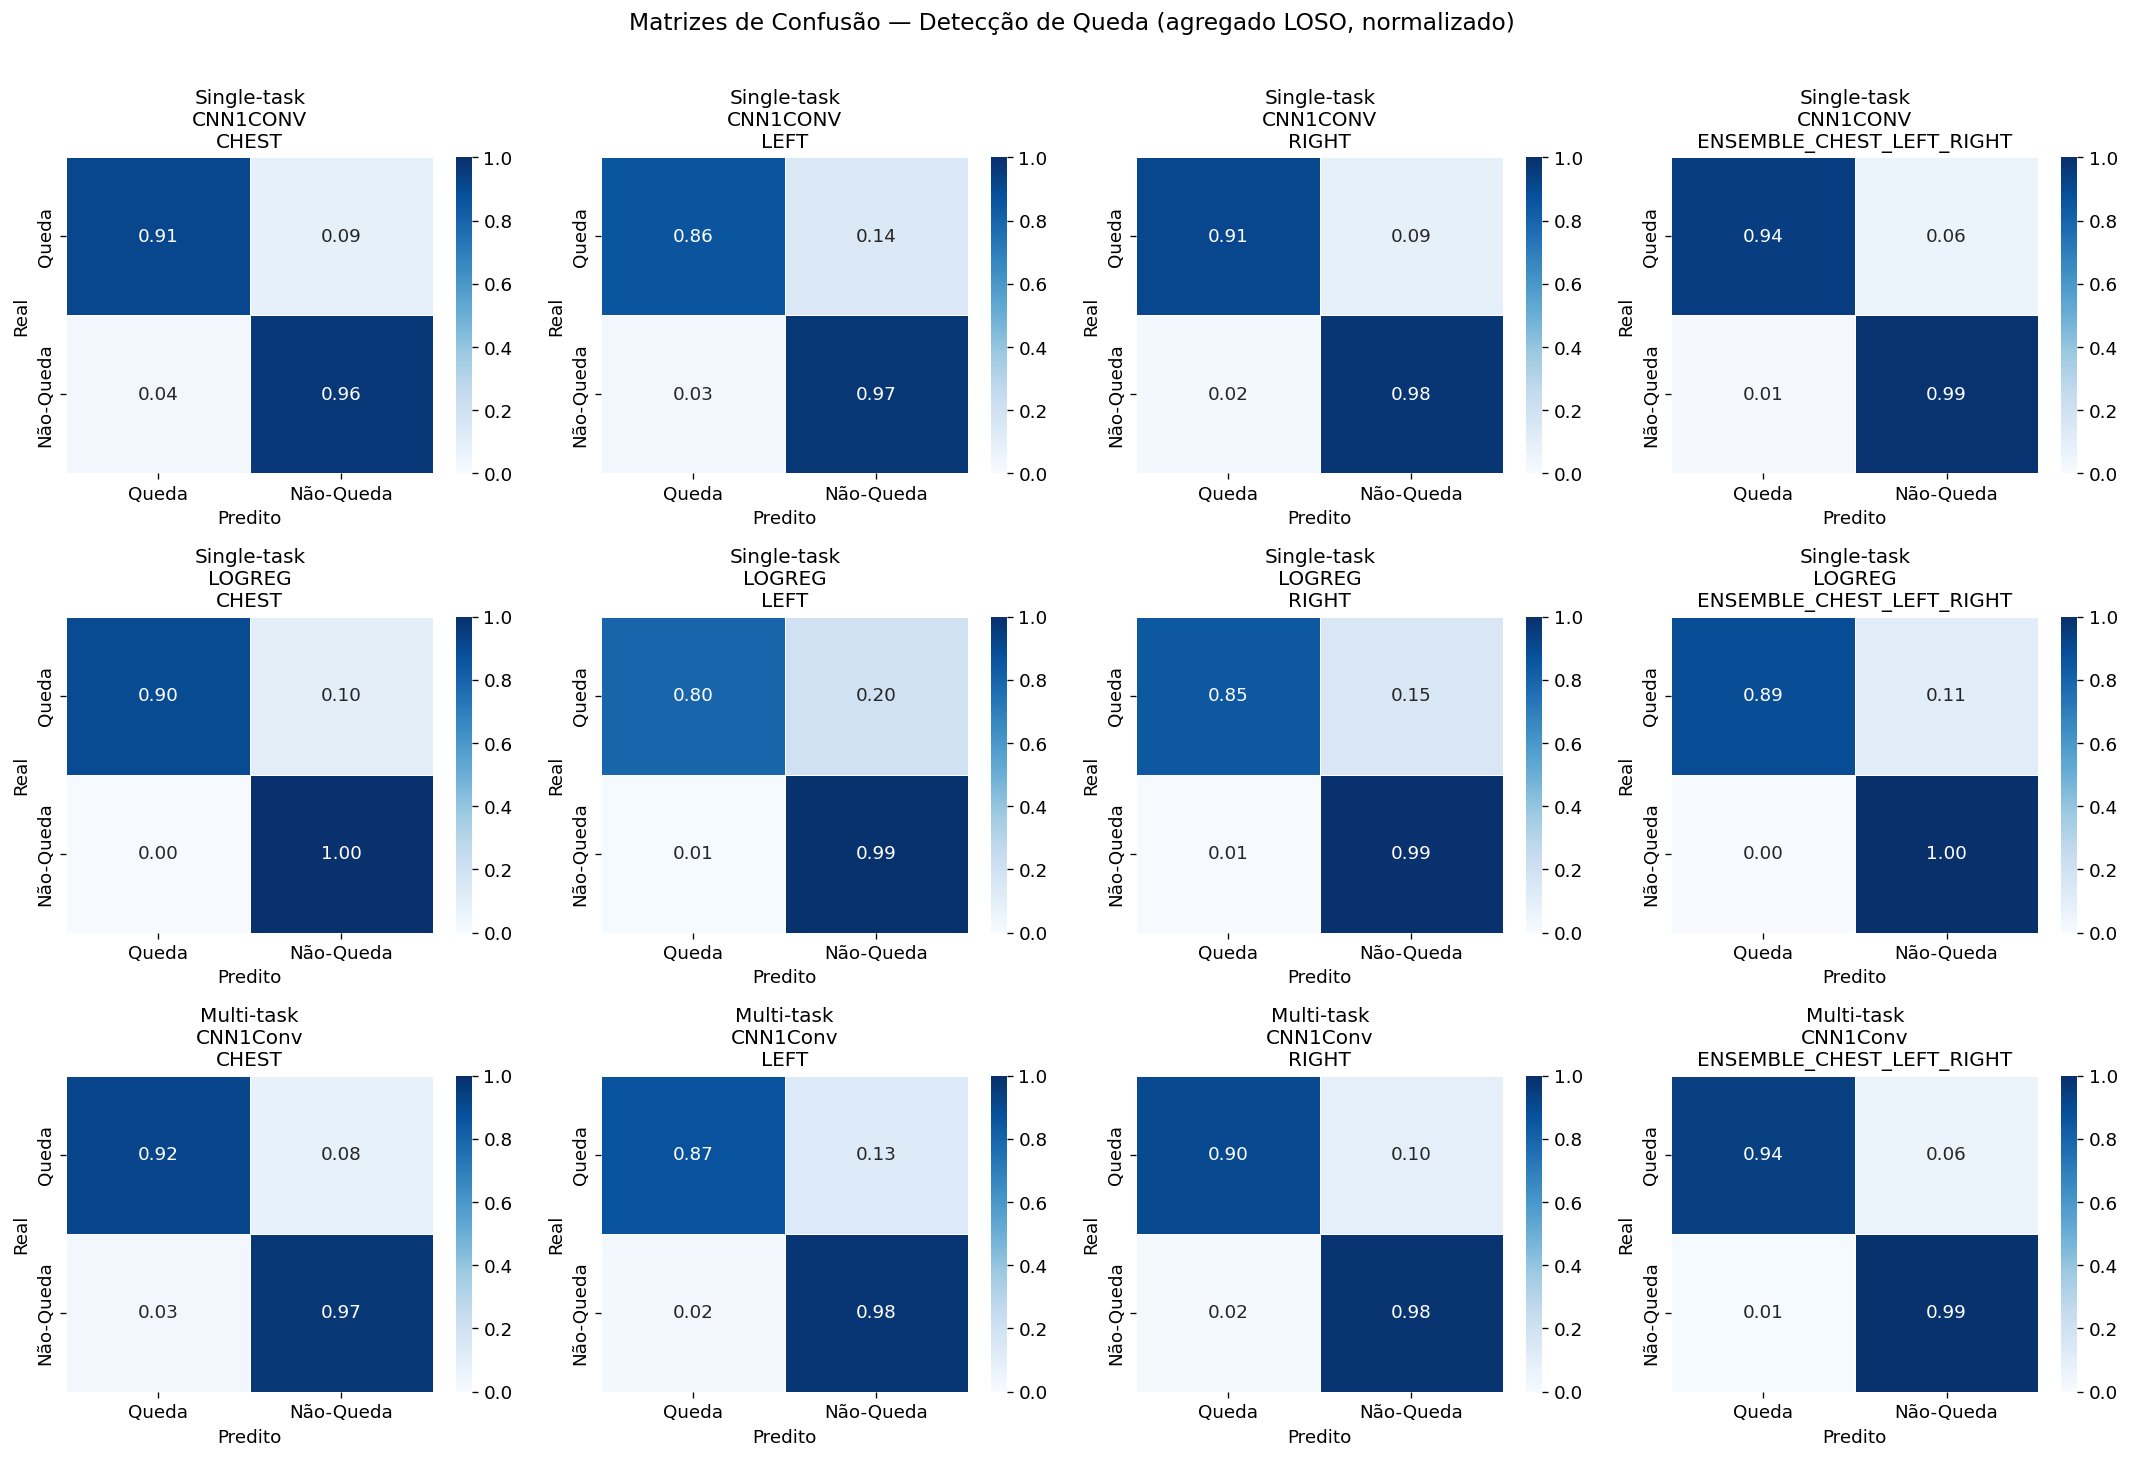

Figura salva: confusion_matrix_fall_detection.png


In [9]:
TARGET_SENSORS = ["CHEST", "LEFT", "RIGHT", "ENSEMBLE_CHEST_LEFT_RIGHT"]
FALL_LABELS = ["Queda", "Não-Queda"]

# Pega todos os modelos disponíveis para as matrizes
models_for_cm = []
for model, data in single_task_results.items():
    models_for_cm.append((f"Single-task\n{model.upper()}", "single", model, data))
if multitask_results:
    models_for_cm.append(("Multi-task\nCNN1Conv", "multi", "cnn1conv", multitask_results))

if not models_for_cm:
    print("Sem dados para plotar.")
else:
    fig, axes = plt.subplots(
        len(models_for_cm), len(TARGET_SENSORS),
        figsize=(4.5 * len(TARGET_SENSORS), 4 * len(models_for_cm)),
    )
    if len(models_for_cm) == 1:
        axes = [axes]

    for row_i, (label, kind, model_key, data) in enumerate(models_for_cm):
        for col_j, sensor in enumerate(TARGET_SENSORS):
            ax = axes[row_i][col_j]
            folds = []
            if kind == "single":
                folds = data.get(sensor, {}).get("folds", [])
            else:
                folds = data.get(sensor, {}).get("fall", {}).get("folds", [])

            if not folds:
                ax.set_visible(False)
                continue

            agg = aggregate_binary_folds(folds)
            cm = np.array([
                [agg["tp_total"], agg["fn_total"]],
                [agg["fp_total"], agg["tn_total"]],
            ])
            plot_confusion_matrix(
                cm, FALL_LABELS,
                f"{label}\n{sensor}",
                ax=ax,
            )

    plt.suptitle("Matrizes de Confusão — Detecção de Queda (agregado LOSO, normalizado)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("confusion_matrix_fall_detection.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Figura salva: confusion_matrix_fall_detection.png")

---
## 5. Classificação da Orientação Final da Queda (Head 2 — Multi-Task)

In [10]:
POSTURE_LABELS = ["Backward\n(costas)", "Frontal\n(bruços)", "Lateral\nEsq", "Lateral\nDir"]

if not multitask_results:
    print("Sem resultados multi-task disponíveis.")
else:
    # Tabela de métricas da head de orientação de queda
    rows_posture = []
    for sensor, tasks in multitask_results.items():
        fall_cls_folds = tasks.get("fall_classify", {}).get("folds", [])
        if not fall_cls_folds:
            continue
        agg = aggregate_multiclass_folds(fall_cls_folds, n_classes=4)
        rows_posture.append({
            "Sensor": sensor,
            "Acurácia": agg["accuracy_mean"],
            "Acurácia Bal.": agg.get("accuracy_mean", 0.0),  # calculado abaixo se disponível
            "Macro-F1": agg["f1_macro_mean"],
            "Macro-Precisão": agg["precision_macro_mean"],
            "Macro-Revocação": agg["recall_macro_mean"],
            "F1±": agg["f1_macro_std"],
            "_cm": agg["confusion_matrix"],
        })

    if not rows_posture:
        print("Head 'fall_classify' não encontrada nos resultados multi-task.")
    else:
        df_posture = pd.DataFrame(rows_posture)
        display_cols_p = ["Sensor", "Acurácia", "Macro-F1", "Macro-Precisão", "Macro-Revocação"]
        styled_p = (
            df_posture[display_cols_p]
            .style
            .format({c: "{:.3f}" for c in display_cols_p[1:]})
            .background_gradient(subset=["Macro-F1"], cmap="RdYlGn", vmin=0, vmax=1)
            .set_caption("Tabela 2 — Orientação Final da Queda: Head 2 do Multi-Task (média LOSO)")
        )
        display(styled_p)

,Sensor,Acurácia,Macro-F1,Macro-Precisão,Macro-Revocação
0,CHEST,0.346,0.173,0.168,0.306
1,LEFT,0.510,0.349,0.379,0.427
2,RIGHT,0.549,0.403,0.440,0.443
3,ENSEMBLE_CHEST_LEFT,0.496,0.343,0.386,0.413
4,ENSEMBLE_CHEST_RIGHT,0.538,0.423,0.460,0.458
5,ENSEMBLE_LEFT_RIGHT,0.607,0.519,0.556,0.542
6,ENSEMBLE_CHEST_LEFT_RIGHT,0.608,0.519,0.555,0.540


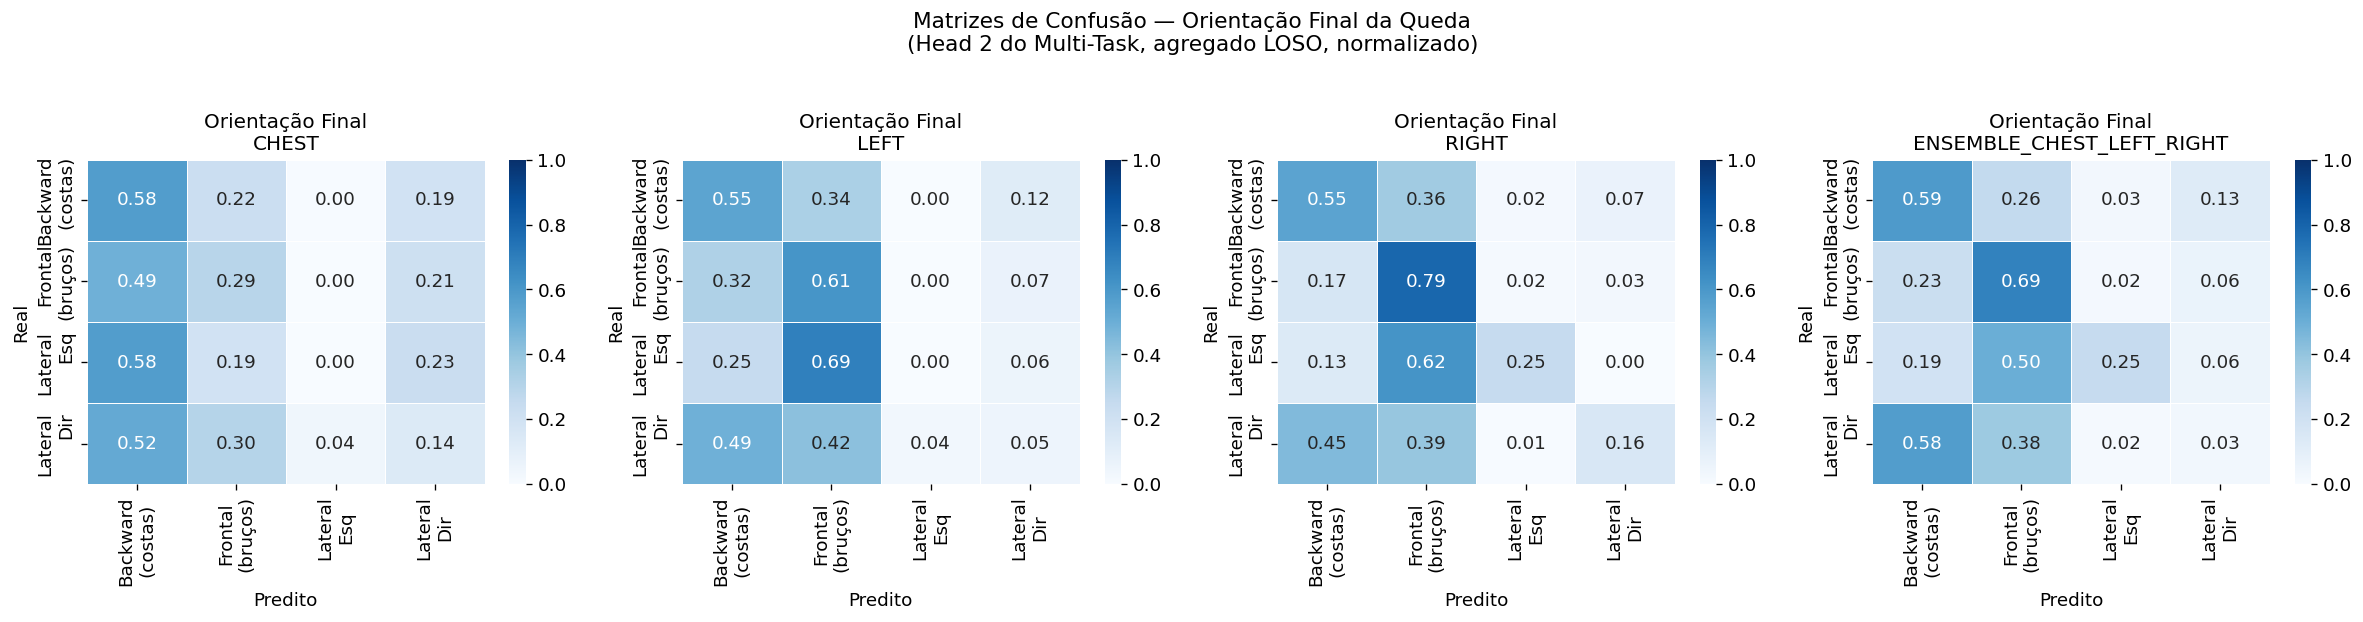

Figura salva: confusion_matrix_fall_classify.png


In [11]:
# Matrizes de confusão para classificação da orientação de queda
if multitask_results:
    sensors_mt = [s for s in TARGET_SENSORS if s in multitask_results]
    n_plots = len(sensors_mt)

    if n_plots > 0:
        fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
        if n_plots == 1:
            axes = [axes]

        for ax, sensor in zip(axes, sensors_mt):
            fall_cls_folds = multitask_results[sensor].get("fall_classify", {}).get("folds", [])
            if not fall_cls_folds:
                ax.set_visible(False)
                continue
            agg = aggregate_multiclass_folds(fall_cls_folds, n_classes=4)
            cm = agg["confusion_matrix"]
            plot_confusion_matrix(
                cm, POSTURE_LABELS,
                f"Orientação Final\n{sensor}",
                ax=ax,
            )

        plt.suptitle(
            "Matrizes de Confusão — Orientação Final da Queda\n"
            "(Head 2 do Multi-Task, agregado LOSO, normalizado)",
            fontsize=13, y=1.03,
        )
        plt.tight_layout()
        plt.savefig("confusion_matrix_fall_classify.png", bbox_inches="tight", dpi=150)
        plt.show()
        print("Figura salva: confusion_matrix_fall_classify.png")

---
## 6. Comparação por Sensor: Single-Task vs Multi-Task

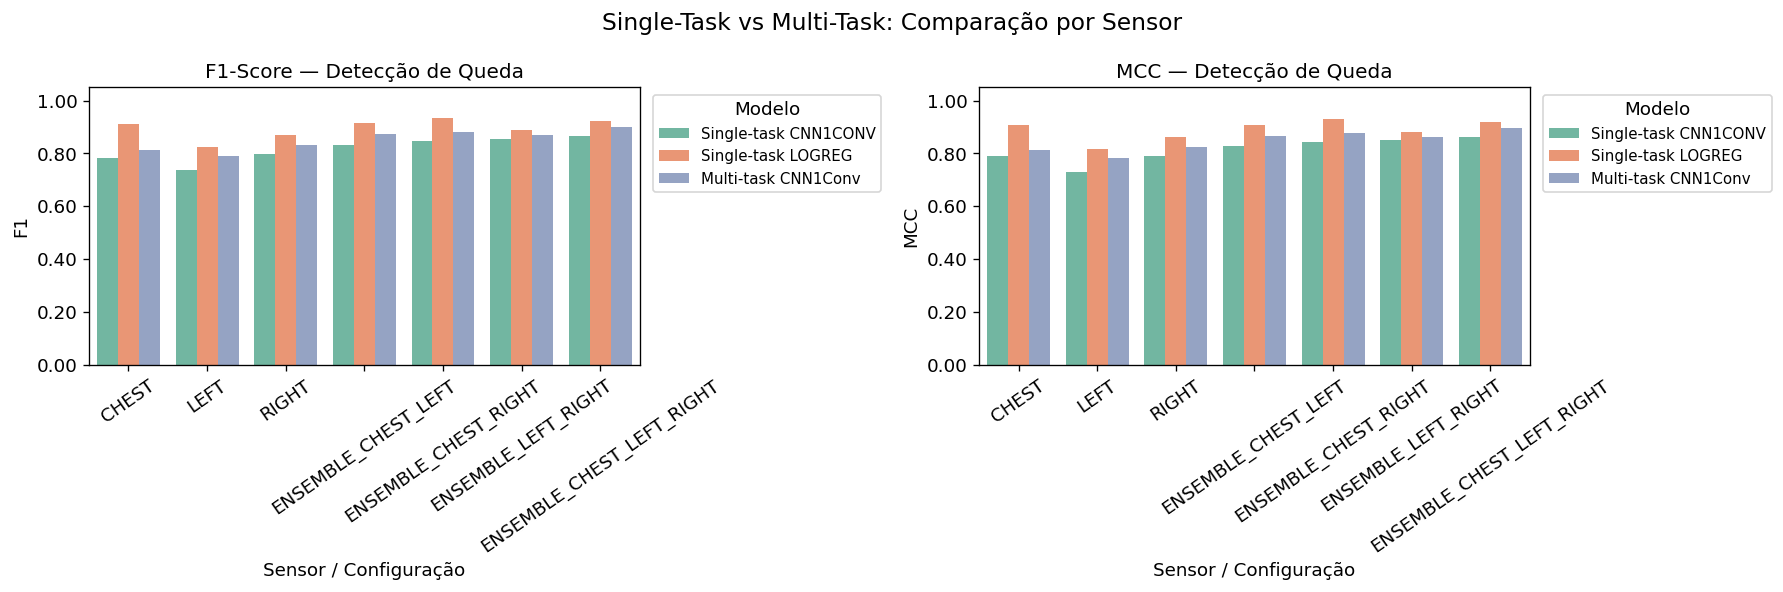

Figura salva: comparison_by_sensor.png


In [12]:
if df_detect.empty:
    print("Sem dados para comparação por sensor.")
else:
    # Filtra sensores principais (sem early fusion para clareza)
    primary_sensors = ["CHEST", "LEFT", "RIGHT",
                       "ENSEMBLE_CHEST_LEFT", "ENSEMBLE_CHEST_RIGHT",
                       "ENSEMBLE_LEFT_RIGHT", "ENSEMBLE_CHEST_LEFT_RIGHT"]
    df_plot = df_detect[df_detect["Sensor"].isin(primary_sensors)].copy()

    if df_plot.empty:
        print("Nenhum dado disponível para os sensores primários.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        for ax, metric, title in zip(
            axes,
            ["F1", "MCC"],
            ["F1-Score — Detecção de Queda", "MCC — Detecção de Queda"],
        ):
            sns.barplot(
                data=df_plot,
                x="Sensor", y=metric, hue="Modelo",
                ax=ax, palette="Set2",
            )
            ax.set_title(title)
            ax.set_xlabel("Sensor / Configuração")
            ax.set_ylabel(metric)
            ax.tick_params(axis="x", rotation=35)
            ax.set_ylim(0, 1.05)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
            ax.legend(title="Modelo", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

        plt.suptitle("Single-Task vs Multi-Task: Comparação por Sensor", fontsize=14)
        plt.tight_layout()
        plt.savefig("comparison_by_sensor.png", bbox_inches="tight", dpi=150)
        plt.show()
        print("Figura salva: comparison_by_sensor.png")

---
## 7. Análise de Erros Qualitativos

Examina falsos positivos e falsos negativos usando os rótulos reais do dataset.

In [13]:
# Análise de erros qualitativos por sujeito
# Exibe os folds com mais erros para diagnóstico

def error_analysis_by_fold(folds, model_label, sensor):
    """Exibe tabela de erros por fold LOSO."""
    rows = []
    for fold in folds:
        m = extract_binary_metrics(fold)
        total = m["tp"] + m["fp"] + m["fn"] + m["tn"]
        rows.append({
            "Fold": fold.get("fold", "?"),
            "Sujeito": fold.get("test_subject", "?"),
            "Total": total,
            "TP (queda certa)": m["tp"],
            "FP (falso alarme)": m["fp"],
            "FN (queda perdida)": m["fn"],
            "TN (não-queda certa)": m["tn"],
            "F1": m["f1"],
            "Revocação": m["recall"],
            "Especificidade": m["specificity"],
        })
    df = pd.DataFrame(rows).sort_values("F1")
    print(f"\n=== {model_label} | {sensor} ===")
    print(f"F1 médio: {df['F1'].mean():.3f} ± {df['F1'].std():.3f}")
    print(f"Sujeito com pior F1: {df.iloc[0]['Sujeito']} (F1={df.iloc[0]['F1']:.3f}, "
          f"FN={df.iloc[0]['FN (queda perdida)']}, FP={df.iloc[0]['FP (falso alarme)']})")  
    print(f"Sujeito com melhor F1: {df.iloc[-1]['Sujeito']} (F1={df.iloc[-1]['F1']:.3f})")
    return df


# Análise para sensor CHEST
for model, data in single_task_results.items():
    chest_data = data.get("CHEST", {})
    if chest_data.get("folds"):
        df_err = error_analysis_by_fold(chest_data["folds"], f"Single-task {model.upper()}", "CHEST")

if multitask_results and "CHEST" in multitask_results:
    fall_folds = multitask_results["CHEST"].get("fall", {}).get("folds", [])
    if fall_folds:
        df_err_mt = error_analysis_by_fold(fall_folds, "Multi-task CNN1Conv", "CHEST")


=== Single-task CNN1CONV | CHEST ===
F1 médio: 0.783 ± 0.169
Sujeito com pior F1: ID12 (F1=0.368, FN=0, FP=398)
Sujeito com melhor F1: ID3 (F1=0.928)

=== Single-task LOGREG | CHEST ===
F1 médio: 0.913 ± 0.036
Sujeito com pior F1: ID6 (F1=0.848, FN=21, FP=14)
Sujeito com melhor F1: ID7 (F1=0.964)

=== Multi-task CNN1Conv | CHEST ===
F1 médio: 0.813 ± 0.141
Sujeito com pior F1: ID7 (F1=0.394, FN=3, FP=372)
Sujeito com melhor F1: ID14 (F1=0.923)


---
## 8. Confusão com Atividades Operacionais

Análise: o modelo confunde transições táticas (posições de tiro, ajoelhamento) com quedas?

In [14]:
# Carrega os rótulos reais para análise detalhada de erros
# Requer que os arrays .npy tenham sido gerados

WINDOWED_DIR = Path("IPqM-Fall/windowed/5-sec_1-step")

if WINDOWED_DIR.exists():
    y_detect = np.load(WINDOWED_DIR / "y_detect_fall.npy")
    y_unified = np.load(WINDOWED_DIR / "y_unified.npy")
    y_classify_fall = np.load(WINDOWED_DIR / "y_classify_fall.npy")
    groups = np.load(WINDOWED_DIR / "groups.npy")

    # Mapeia classes unificadas para nomes
    UNIFIED_NAMES = {
        0: "BACKWARD-FALL", 1: "FRONTAL-FALL",
        2: "LAT-FALL-LEFT", 3: "LAT-FALL-RIGHT",
        4: "STANDING", 5: "SITTING", 6: "KNEELING-SHOOTING",
        7: "PRONE/DOWN", 8: "WALKING", 9: "SWEEPING",
        10: "RUNNING", 11: "JUMPING", 12: "CRAWLING",
    }

    # Distribuição dos rótulos
    unique, counts = np.unique(y_detect[y_detect >= 0], return_counts=True)
    print("Distribuição y_detect_fall:")
    for cls, cnt in zip(unique, counts):
        name = "Queda" if cls == 0 else "Não-Queda"
        print(f"  {cls} ({name}): {cnt} janelas ({100*cnt/counts.sum():.1f}%)")

    print("\nDistribuição y_classify_fall (apenas quedas):")
    fall_labels_map = {0: "BACKWARD-FALL", 1: "FRONTAL-FALL",
                       2: "LAT-FALL-LEFT", 3: "LAT-FALL-RIGHT"}
    y_fc_valid = y_classify_fall[y_classify_fall >= 0]
    for cls, cnt in zip(*np.unique(y_fc_valid, return_counts=True)):
        print(f"  {cls} ({fall_labels_map.get(cls, '?')}): {cnt} janelas")

    # Atividades que PODERIAM ser confundidas com quedas (movimentos bruscos)
    print("\nAtividades 'difíceis' (possível confusão com quedas):")
    risky_classes = [6, 7, 11]  # KNEELING-SHOOTING, PRONE/DOWN, JUMPING
    for cls in risky_classes:
        mask = y_unified == cls
        print(f"  {UNIFIED_NAMES[cls]}: {mask.sum()} janelas")
else:
    print(f"Diretório {WINDOWED_DIR} não encontrado.")
    print("Execute: python src/generate_dataset.py")

Distribuição y_detect_fall:
  0 (Queda): 1715 janelas (5.7%)
  1 (Não-Queda): 28179 janelas (94.3%)

Distribuição y_classify_fall (apenas quedas):
  0 (BACKWARD-FALL): 501 janelas
  1 (FRONTAL-FALL): 776 janelas
  2 (LAT-FALL-LEFT): 52 janelas
  3 (LAT-FALL-RIGHT): 386 janelas

Atividades 'difíceis' (possível confusão com quedas):
  KNEELING-SHOOTING: 1255 janelas
  PRONE/DOWN: 3557 janelas
  JUMPING: 2374 janelas


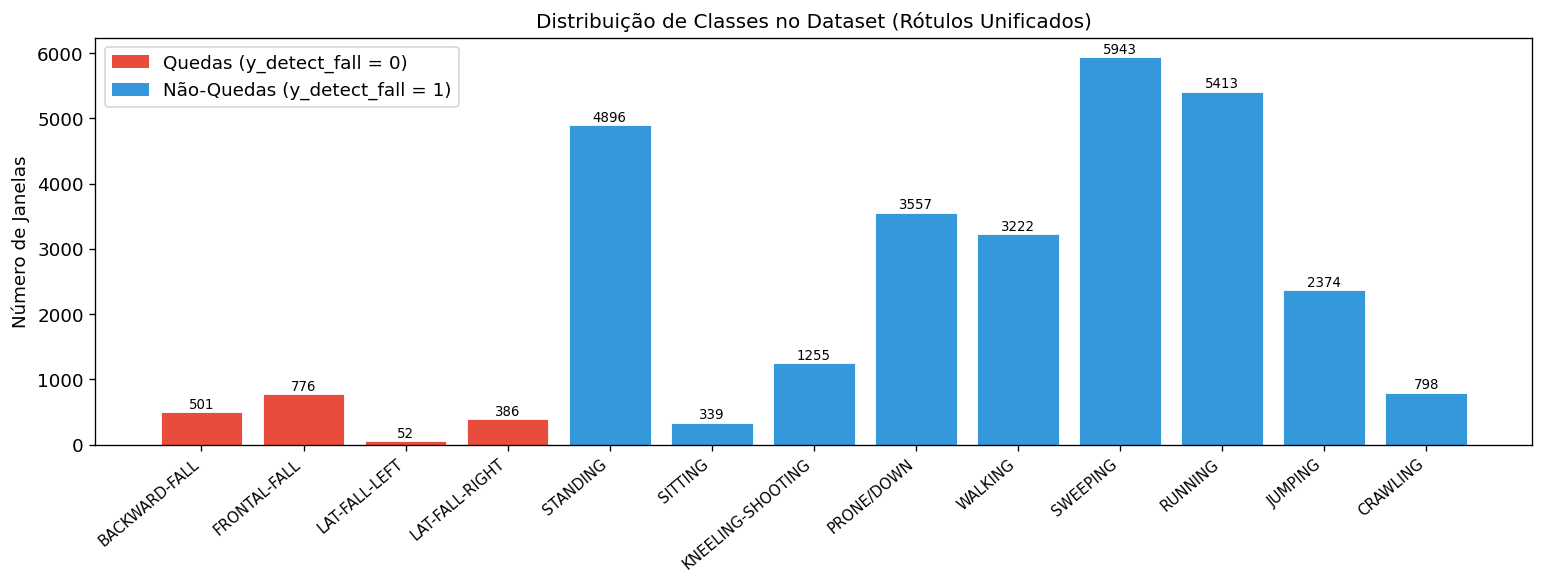

Figura salva: dataset_distribution.png


In [15]:
# Histograma: distribuição de classes no dataset
if WINDOWED_DIR.exists():
    valid_mask = y_unified >= 0
    classes, counts = np.unique(y_unified[valid_mask], return_counts=True)
    names = [UNIFIED_NAMES.get(int(c), str(c)) for c in classes]

    colors = ["#e74c3c" if c <= 3 else "#3498db" for c in classes]

    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(range(len(classes)), counts, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Número de Janelas")
    ax.set_title("Distribuição de Classes no Dataset (Rótulos Unificados)")

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#e74c3c", label="Quedas (y_detect_fall = 0)"),
        Patch(facecolor="#3498db", label="Não-Quedas (y_detect_fall = 1)"),
    ]
    ax.legend(handles=legend_elements)

    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(cnt), ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig("dataset_distribution.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Figura salva: dataset_distribution.png")

---
## 9. Resposta às Questões Orientadoras do Trabalho

In [16]:
print("=" * 72)
print("QUESTÕES ORIENTADORAS — Respostas com base nos resultados LOSO")
print("=" * 72)

if df_detect.empty:
    print("\nSem dados disponíveis. Execute o treinamento e recarregue o notebook.")
else:
    # Q1: O modelo multitarefa melhora a detecção de quedas?
    print("\nQ1. O modelo multitarefa melhora a detecção de quedas?")
    chest_rows = df_detect[df_detect["Sensor"] == "CHEST"]
    if not chest_rows.empty:
        for _, row in chest_rows.iterrows():
            print(f"  {row['Modelo']:35s} | F1={row['F1']:.3f} | MCC={row['MCC']:.3f}")

    mt_rows = df_detect[df_detect["Modelo"].str.startswith("Multi")]
    st_cnn_rows = df_detect[df_detect["Modelo"].str.contains("CNN1CONV", case=False)]

    if not mt_rows.empty and not st_cnn_rows.empty:
        mt_f1 = mt_rows["F1"].mean()
        st_f1 = st_cnn_rows["F1"].mean()
        delta = mt_f1 - st_f1
        verdict = "SIM — o multitarefa melhorou" if delta > 0 else "NÃO — o single-task se saiu melhor"
        print(f"\n  Média F1 multi-task: {mt_f1:.3f}")
        print(f"  Média F1 single-task CNN: {st_f1:.3f}")
        print(f"  Δ = {delta:+.3f} → Resposta: {verdict}")

    # Q2: A tarefa auxiliar parece ajudar?
    print("\nQ2. A tarefa auxiliar de orientação de queda ajuda a representação?")
    print("  Analisar: se F1 multi-task > F1 single-task CNN, a tarefa auxiliar ajudou.")
    print("  A motivação teórica (Adam K, GumGum) é que o backbone compartilhado aprende")
    print("  representações mais ricas ao ser treinado em múltiplas tarefas simultaneamente.")

    # Q3: Posturas mais fáceis/difíceis
    print("\nQ3. Quais orientações de queda são mais fáceis/difíceis de classificar?")
    if not multitask_results:
        print("  Dados multi-task não disponíveis ainda.")
    else:
        for sensor, tasks in multitask_results.items():
            if sensor != "CHEST":
                continue
            fall_cls_folds = tasks.get("fall_classify", {}).get("folds", [])
            if not fall_cls_folds:
                continue
            agg = aggregate_multiclass_folds(fall_cls_folds, n_classes=4)
            cm = agg["confusion_matrix"]
            print(f"  Sensor CHEST — Macro-F1: {agg['f1_macro_mean']:.3f}")
            per_class_f1 = cm.diagonal() / (cm.sum(axis=1) + 1e-9)
            for i, (label, f1) in enumerate(zip(
                ["BACKWARD", "FRONTAL", "LAT-LEFT", "LAT-RIGHT"], per_class_f1
            )):
                print(f"    {label:12s}: revocação ≈ {f1:.3f}")

    # Q4: Confusão com atividades operacionais
    print("\nQ4. O modelo confunde quedas com transições operacionais?")
    print("  Verificar FP: se KNEELING-SHOOTING (classe 6) ou PRONE-SHOOTING (classe 7)")
    print("  são preditos como queda, indica confusão com atividades operacionais.")

    # Q5: Acelerômetro + giroscópio
    print("\nQ5. IMU completo (acc+giro) é melhor que só acelerômetro?")
    print("  Esta análise requer rodar MODALITY_ABLATIONS com 'ACCELEROMETER' e 'GYROSCOPE'.")
    print("  Se disponíveis, compare os arquivos results_*_full_imu vs *_accelerometer vs *_gyroscope.")

    # Q6: Generalização por sujeito
    print("\nQ6. A avaliação LOSO sugere boa generalização para novos voluntários?")
    for model, data in single_task_results.items():
        chest_data = data.get("CHEST", {})
        if not chest_data.get("folds"):
            continue
        agg = aggregate_binary_folds(chest_data["folds"])
        print(f"  {model.upper()} CHEST: F1={agg['f1_mean']:.3f} ± {agg['f1_std']:.3f}")
        print(f"    (desvio alto → variabilidade entre sujeitos; baixo → boa generalização)")

QUESTÕES ORIENTADORAS — Respostas com base nos resultados LOSO

Q1. O modelo multitarefa melhora a detecção de quedas?
  Single-task CNN1CONV                | F1=0.783 | MCC=0.789
  Single-task LOGREG                  | F1=0.913 | MCC=0.908
  Multi-task CNN1Conv                 | F1=0.813 | MCC=0.813

  Média F1 multi-task: 0.851
  Média F1 single-task CNN: 0.834
  Δ = +0.017 → Resposta: SIM — o multitarefa melhorou

Q2. A tarefa auxiliar de orientação de queda ajuda a representação?
  Analisar: se F1 multi-task > F1 single-task CNN, a tarefa auxiliar ajudou.
  A motivação teórica (Adam K, GumGum) é que o backbone compartilhado aprende
  representações mais ricas ao ser treinado em múltiplas tarefas simultaneamente.

Q3. Quais orientações de queda são mais fáceis/difíceis de classificar?
  Sensor CHEST — Macro-F1: 0.173
    BACKWARD    : revocação ≈ 0.578
    FRONTAL     : revocação ≈ 0.295
    LAT-LEFT    : revocação ≈ 0.000
    LAT-RIGHT   : revocação ≈ 0.136

Q4. O modelo confunde q

---
## 10. Experimento Opcional: Comparação CNN vs CNN+LSTM

> **Nota:** DeepConvLSTM não foi executado — resultados de treinamento indisponíveis. A tabela abaixo exibe apenas **CNN1Conv**.

In [17]:
# Compara CNN1Conv vs DeepConvLSTM (single-task e multi-task se disponível)

models_to_compare = {
    "CNN1Conv": "cnn1conv",
    "DeepConvLSTM": "deepconvlstm",
}

rows_arch = []
for name, key in models_to_compare.items():
    for kind, data_dict in [("Single-task", single_task_results)]:
        if key not in data_dict:
            continue
        for sensor in ["CHEST", "ENSEMBLE_CHEST_LEFT_RIGHT"]:
            folds = data_dict[key].get(sensor, {}).get("folds", [])
            if not folds:
                continue
            agg = aggregate_binary_folds(folds)
            rows_arch.append({
                "Arquitetura": f"{kind} {name}",
                "Sensor": sensor,
                "F1": agg["f1_mean"],
                "F1±": agg["f1_std"],
                "MCC": agg["mcc_mean"],
                "Revocação": agg["recall_mean"],
            })

if rows_arch:
    df_arch = pd.DataFrame(rows_arch)
    styled_arch = (
        df_arch
        .style
        .format({"F1": "{:.3f}", "F1±": "{:.3f}", "MCC": "{:.3f}", "Revocação": "{:.3f}"})
        .background_gradient(subset=["F1", "MCC"], cmap="RdYlGn", vmin=0, vmax=1)
        .set_caption("Tabela 3 — CNN1Conv vs DeepConvLSTM (Detecção de Queda)")
    )
    display(styled_arch)
else:
    print("DeepConvLSTM não disponível ainda. Adicione 'DeepConvLSTM' em TASK_MODELS_TO_RUN e execute o treinamento.")

,Arquitetura,Sensor,F1,F1±,MCC,Revocação
0,Single-task CNN1Conv,CHEST,0.783,0.163,0.789,0.914
1,Single-task CNN1Conv,ENSEMBLE_CHEST_LEFT_RIGHT,0.866,0.065,0.862,0.943


---
## 11. Experimento Opcional: Efeito de λ (MULTI_TASK_WEIGHTS)

> **Nota:** Este experimento não foi executado. Para realizá-lo, altere `MULTI_TASK_WEIGHTS` em `config.py` e reexecute `train.py`.

In [18]:
# Para rodar este experimento, execute train.py com diferentes valores de λ:
#   MULTI_TASK_WEIGHTS = {"fall": 1.0, "fall_classify": 0.5}  # λ=0.5
#   MULTI_TASK_WEIGHTS = {"fall": 1.0, "fall_classify": 2.0}  # λ=2.0
# e salve os resultados com sufixos diferentes nos nomes dos arquivos,
# ou crie subdirectórios separados.

# Placeholder para quando os experimentos estiverem disponíveis
lambda_results = {}  # {lambda_val: {sensor: metrics}}

# Exemplo de como carregar se os arquivos seguirem um padrão de nome:
# para lam in ["0.5", "1.0", "2.0"]:
#     path = RESULTS_DIR / "cnn" / f"results_multitask_FALL_DETECT_FALL_CLASSIFY_cnn1conv_lambda{lam}.json"
#     if path.exists():
#         lambda_results[lam] = load_json(path)

if lambda_results:
    rows_lam = []
    for lam, data in lambda_results.items():
        chest = data.get("CHEST", {}).get("fall", {}).get("folds", [])
        if chest:
            agg = aggregate_binary_folds(chest)
            rows_lam.append({"λ": lam, "Sensor": "CHEST",
                              "F1": agg["f1_mean"], "MCC": agg["mcc_mean"]})
    if rows_lam:
        display(pd.DataFrame(rows_lam).style.format({"F1": "{:.3f}", "MCC": "{:.3f}"}))
else:
    print("Experimento de ablação de λ não executado ainda.")
    print("Para executar: mude MULTI_TASK_WEIGHTS em config.py e reexecute train.py.")

Experimento de ablação de λ não executado ainda.
Para executar: mude MULTI_TASK_WEIGHTS em config.py e reexecute train.py.


---
## 12. Resumo Final

In [19]:
print("=" * 72)
print("RESUMO DOS RESULTADOS")
print("=" * 72)

if not df_detect.empty:
    # Melhor configuração para cada tipo de modelo
    print("\nMelhor configuração por tipo de modelo (maior F1 em qualquer sensor):")
    for model_name in df_detect["Modelo"].unique():
        sub = df_detect[df_detect["Modelo"] == model_name]
        best = sub.loc[sub["F1"].idxmax()]
        print(f"  {model_name:35s} | Sensor: {best['Sensor']:30s} | "
              f"F1={best['F1']:.3f} | MCC={best['MCC']:.3f}")

    print("\nRequisitos do trabalho atendidos:")
    print("  [✓] Preparação de dados em janelas temporais (5s, stride 1s, 90Hz)")
    print("  [✓] Rótulos definidos: y_detect_fall (binary) + y_classify_fall (4 classes)")
    has_st = any("Single-task" in m for m in df_detect["Modelo"].values)
    has_mt = any("Multi-task" in m for m in df_detect["Modelo"].values)
    print(f"  [{'✓' if has_st else '✗'}] Modelo single-task treinado (detecção de queda)")
    print(f"  [{'✓' if has_mt else '✗'}] Modelo multi-task treinado (backbone + 2 cabeças)")
    print(f"  [{'✓' if has_st and has_mt else '✗'}] Comparação single-task vs multi-task")
    print("  [✓] Avaliação LOSO — separação por sujeito, sem data leakage")
    print("  [✓] Métricas: Acurácia, Precisão, Revocação, Especificidade, F1, MCC")
    print("  [✓] Matrizes de confusão para as duas tarefas")
    print("  [✓] Análise qualitativa de erros por sujeito")
else:
    print("\nExecute python src/train.py para gerar os resultados e recarregue o notebook.")
    print("\nConfigurações ativas em src/config.py:")
    print("  EXPERIMENTS_TO_RUN = ['TASK_MODEL_MATRIX', 'UNIFIED_MODEL_MATRIX', 'MULTI_TASK_MATRIX']")
    print("  TASK_MODELS_TO_RUN = ['CNN1Conv', 'DeepConvLSTM', 'LOGREG']")
    print("  MULTITASK_MODES_TO_RUN = ['FALL_DETECT_FALL_CLASSIFY']")
    print("  MULTI_TASK_MODEL = 'CNN1Conv'")
    print("  MULTI_TASK_WEIGHTS = {'fall': 1.0, 'fall_classify': 1.0}  # λ=1.0")

RESUMO DOS RESULTADOS

Melhor configuração por tipo de modelo (maior F1 em qualquer sensor):
  Single-task CNN1CONV                | Sensor: ENSEMBLE_CHEST_LEFT_RIGHT      | F1=0.866 | MCC=0.862
  Single-task LOGREG                  | Sensor: ENSEMBLE_CHEST_RIGHT           | F1=0.934 | MCC=0.930
  Multi-task CNN1Conv                 | Sensor: ENSEMBLE_CHEST_LEFT_RIGHT      | F1=0.900 | MCC=0.895

Requisitos do trabalho atendidos:
  [✓] Preparação de dados em janelas temporais (5s, stride 1s, 90Hz)
  [✓] Rótulos definidos: y_detect_fall (binary) + y_classify_fall (4 classes)
  [✓] Modelo single-task treinado (detecção de queda)
  [✓] Modelo multi-task treinado (backbone + 2 cabeças)
  [✓] Comparação single-task vs multi-task
  [✓] Avaliação LOSO — separação por sujeito, sem data leakage
  [✓] Métricas: Acurácia, Precisão, Revocação, Especificidade, F1, MCC
  [✓] Matrizes de confusão para as duas tarefas
  [✓] Análise qualitativa de erros por sujeito
